# Iris Flower Classification

## Objective
The objective of this project is to build a machine learning classification model that can predict the species of an Iris flower based on its sepal and petal measurements.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df["Species"] = df["Species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [5]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

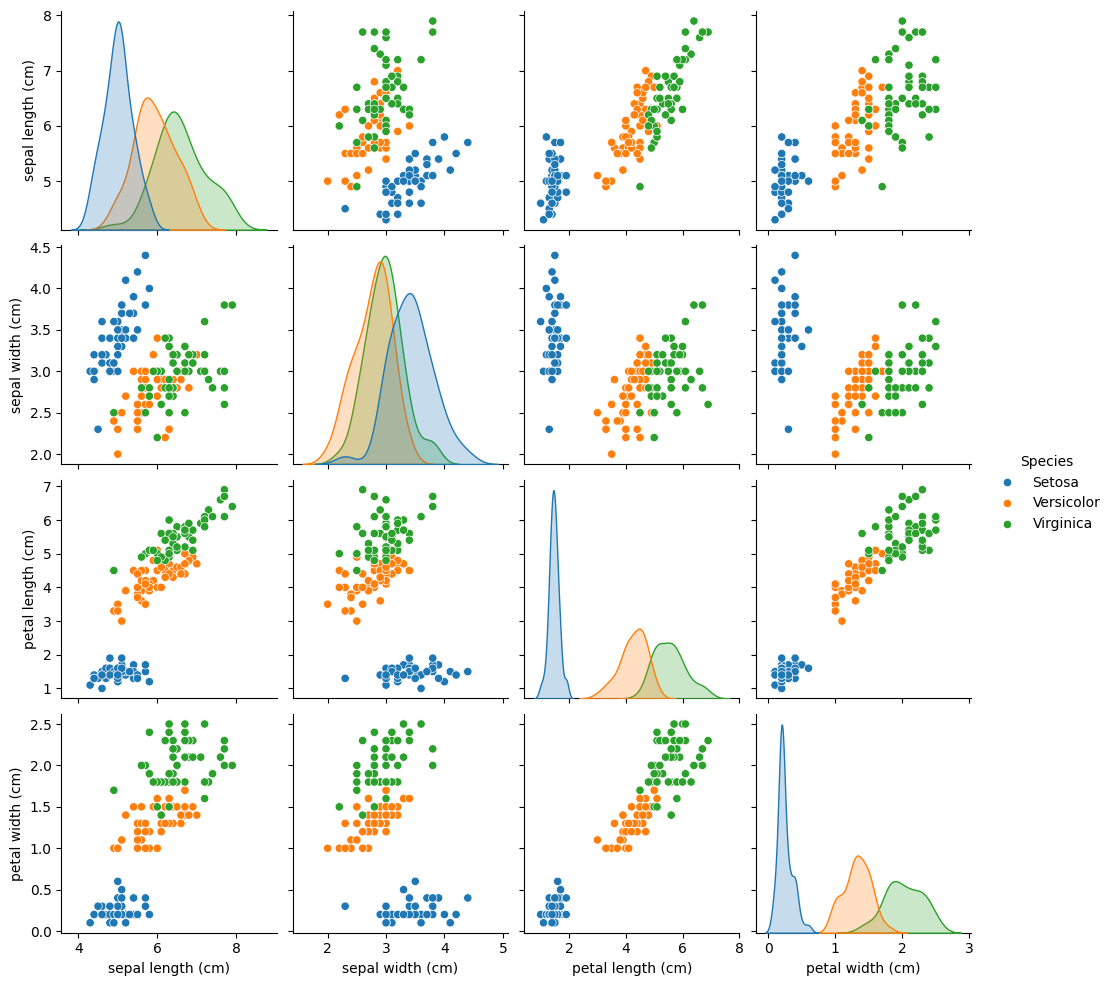

In [6]:
sns.pairplot(df, hue="Species")
plt.show()

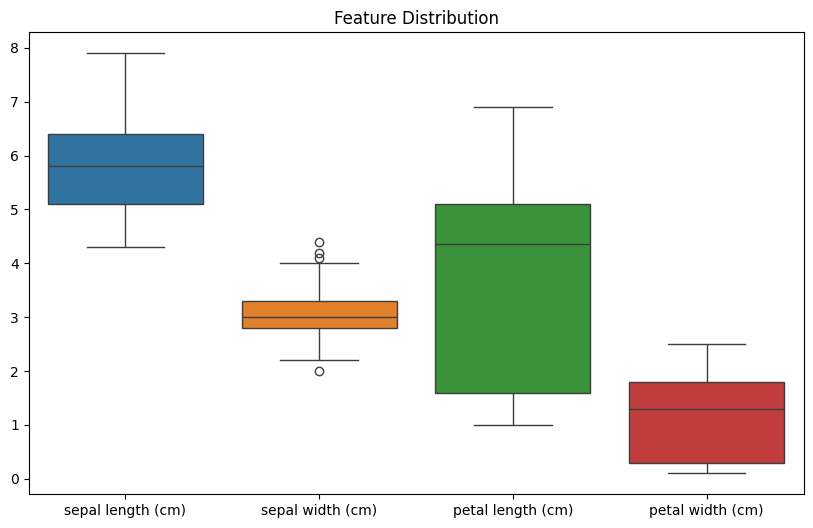

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:,0:4])
plt.title("Feature Distribution")
plt.show()

In [8]:
X = df.drop("Species", axis=1)

y = df["Species"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [10]:
lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [12]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [14]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [16]:
print("Logistic Regression :", accuracy_score(y_test, y_pred_lr))

print("Decision Tree :", accuracy_score(y_test, y_pred_dt))

print("Random Forest :", accuracy_score(y_test, y_pred_rf))

Logistic Regression : 1.0
Decision Tree : 1.0
Random Forest : 1.0


In [17]:
accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

best_model = max(accuracies, key=accuracies.get)

print("Best Model:", best_model)

print("Accuracy:", accuracies[best_model])

Best Model: Logistic Regression
Accuracy: 1.0


# Conclusion

This project successfully classified Iris flowers into Setosa, Versicolor, and Virginica using Machine Learning.

The dataset was explored through EDA, visualized using pairplots and boxplots, and split into training and testing datasets.

Three machine learning models were trained:
- Logistic Regression
- Decision Tree
- Random Forest

The model with the highest accuracy was selected as the best-performing model.

This project demonstrates the complete machine learning workflow from data exploration to model evaluation.

# Feature Selection

Among the four features, petal length and petal width are the most discriminative features because they clearly separate the three Iris species. Sepal length and sepal width also contribute to classification but show more overlap between Versicolor and Virginica.

# Best Performing Model

After comparing the accuracy of all three models, the model with the highest accuracy was selected as the best-performing model. This model provides the most reliable predictions for classifying Iris flower species.